머신러닝
- 지도 : 학습할 떄 결과값(label)이 포함된 데이터<br> ex) classification(분류)(KNN), 회귀 regression
  - KNN : 근접한 K개의 이웃을 확인해서 class를 분류하는 것 <br>
      데이터에 더 많은 영향 받는다.<br>
      k 선택시 데이터의 클래스 수보다 큰값으로 정한다.(중복되는 것을 막기 위해) <br>
        ex)blue, green, red class : 하나씩 나오는 것을 막기 위해
- 비지도 : Label(결과값)이 없는 데이터 -> 특성/패턴 존재 <br>ex) 클러스터링, 차원축소
- 강화 : 에이전트의 동작에 대해서 '보상'을 주어 최적의동작으로 움직이는 방법<br>
ex) 게임플레이



### 머신러닝 프로세스 / 파이프라인
  목표설정/문제정의 → 데이터 추출(수집) → 데이터 전처리(정제) → (데이터 분할 traindata & testdata) → 모델 학습(train) → 모델평가(train, test 모두)

  - 평가 후 성능이 낮을 시에 모델학습을 다시하게 된다.<br>
  하이퍼파라미터, 데이터분할부터 다시 할 수도 있다.<br>
  이런식으로 앞단계로 가서 잘못된걸 바로 잡는 느낌

모델 학습 시 필요한 변수
- 파라미터 : 머신이 학습하는 변수 (가중치, bias)
- 하이퍼파라미터 : 개발자가 지정하는 값<br>
→ 반복문을 통해 결과 비교, 그리드 서치로 알아낼 수 있다./

  train 정확도 , test 정확도 그래프로도 알수 있는데, gap(차이)이 작은 지점을 비교
  - 둘다 일정 수준 이하 : underfitting 과소적합
  - train 정확도 높고, test 정확도 낮을 때 : 과대적합 overfitting
  - 모두 괜찮을 때 train 정확도 < test 정확도로 정할 수 있다. <br>test 정확도가 높다는 것은 새로운 데이터에 대한 정확도가 높다고 판단하기 때문이다.

          train : 데이터를 잘 설명했는지
          test  : 일반화가 잘 되었는지

# Regression Model
- 하나 혹은 그 이상의 특성들이 연속형 레이블에 미치는 영향을 추정하는 통계 기법
- 수학적 모델을 가정하여 측정된 변수들의 데이터들로부터 추정하는 통계적 방법
- 특성값(X)를 이용하여 연속형 레이블(Y)을 예측

## 회귀분석의 종류
- 단순 선형 회귀분석
    - 특성의 개수가 1개이며, 레이블과의 관계가 직선인 경우
- 다중 선형 회귀분석
    - 특성의 개수가 N개이며, 레이블과의 관계가 선형인 겨우(1차 함수)
- 다항 회귀분석
    - 특성의 개수가 N개이며, 레이블과의 관계가 비선형인 경우 (2차 함수 이상)
- 비선형 회귀분석
    - 회귀식의 모양이 선형관계로 이루어져있지 않는 모델

비선형은 로그, 지수등

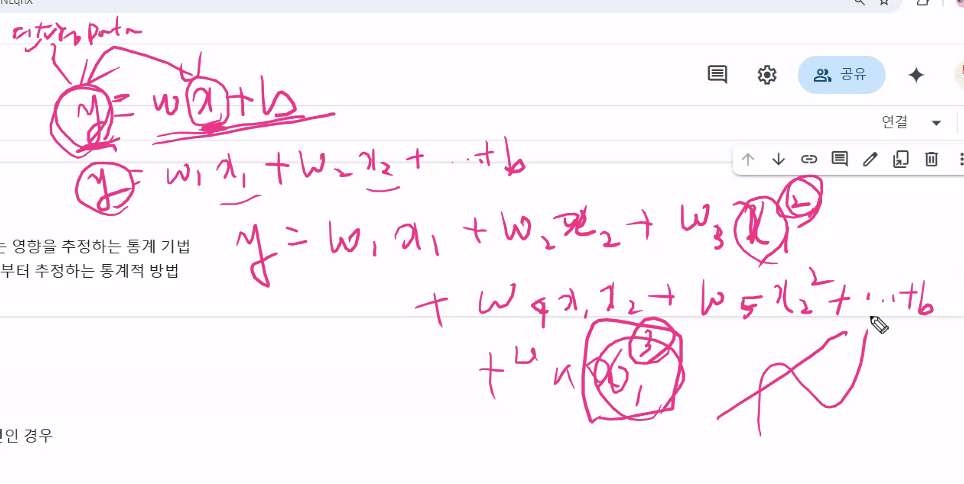

회귀분석 기본 식 $y = wx + b$

## 회귀분석 성능평가 척도
- $R^2$ : R-Squared (결정계수)
```
sklearn.metrics.r2_score
```
    - $R^2 = 1 - \frac{\sum(y - \hat{y})^2}{\sum(y - \overline{y})^2}$
    - 실제 값의 분산 대비 예측값의 분산 비율
    - 최고값은 1, 최악은 음수로 실제보다 더 나쁜 예측을 하는 모델
    - 모델 예측 성능(설명력)을 평가하는 목적

- $MAE$ : Mean Absolute Error (평균 절대값 오차)
```
sklearn.metrics.mean_absolute_error
```
    - $MAE = \frac{1}{m} \sum_{i=1}^m |y-\hat{y}|$
    - 실제 값과 예측 값의 차이를 절대값으로 변환해 평균 계산
    - 오차의 크기를 그대로 반영하여 오차 평균 크기를 확인하는 목적
    - 작을수록 좋음

- $MSE$ : Mean Squared Error (평균 제곱 오차)
```
sklearn.metrics.mean_squared_error
```
    - $MSE = \frac{1}{m} \sum_{i=1}^m (y-\hat{y})^2$
    - 실제 값과 예측 값의 차이를 제곱하여 평균 계산
    - 큰 오차를 더 크게, 작은 오차는 더 작게 평가하여 이상치에 민감
    
- $RMSE$ : Root Mean Squared Error (평균 제곱 오차의 제곱근)
```
numpy.sqrt(mse)
```
    - $RMSE = \sqrt{\frac{1}{m} \sum_{i=1}^m (y-\hat{y})^2}$
    - MSE의 크기를 줄이기 위한 목적으로 사용
    - MSE에 비해 이상치에 대해 덜 민감
    

## Linear Regression (선형 회귀분석)
- 레이블과 1개 이상의 특성과의 선형 상관관계를 모델링하는 회귀분석 기법
    - 레이블과 연관있는 특성이 존재하는 경우 관계르 정량화할 수 있음
    - 단순 회귀 분석
$y = wx + b$
    - 다중 회귀 분석
$y = w_1x_1 + w_2x_2 + \cdots + w_nx_n + b$
- 연속형 레이블 값을 예측하는 목적일 경우, 선형 회귀를 사용해 데이터에 적합한 예측 모델을 개발할 수 있음
- Linear Regression의 구현방법으로는 최소 제곱법과 경사하강법이 존재

### 최소제곱법 (Ordinary Least Squares)
- 잔차(Residual Error) 제곱의 합이 최소가 되도록 가중치(Weight)와 편향(Bias)을 찾음
    - 잔차 : 실제값
$y$과 예측값 $\hat{y}$의 차이
- 잔차 제곱의 합(Residual Sum of Squares)이 최소가 되는 가중치와 편향은 편미분을 통해 도출
    - 미분값이 0이 도출되는 값이 임계점이 되기 때문에 각각의 편미분값이 0인 가중치와 편향의 식을 연립방정식으로 계산
- 장점
    - 간단하게 식을 유도할 수 있음
- 단점
    - 데이터가 많아지면 계산량이 매우 많이 증가
    - 데이터에 이상치가 있는 경우 성능 하락

$RSS(w,b) = \sum_{i=1}^n (y_i - (wx_i + b))^2$
- 오차 제곱합을 최소화하기 위한 편미분 <br>
    - $w$에 대해 편미분<br>
    $\frac{\partial SS}{\partial w} = \frac{\partial}{\partial{w}} \sum_{i=1}^n (y_i - (w + b x_i))^2 = -2 \sum_{i=1}^n (y_i - (w + b x_i))$<br>
    - $b$에 대해 편미분 <br>
    $\frac{\partial SS}{\partial b} = \frac{\partial}{\partial{b}} \sum_{i=1}^n (y_i - (w + b x_i))^2 = -2 \sum_{i=1}^n x_i(y_i - (w + b x_i))$<br>
    - 최소화하기 위한 편미분값은 0 <br>
    $\sum_{i=1}^n (y_i - (w + b x_i))=0 \Rightarrow b = \overline{y} - w\overline{x}$ <br>
    $\sum_{i=1}^n (y_i - (w + b x_i))=0 \Rightarrow w = \frac{\sum_{i=1}^nx_i(y_i-\overline{y})}{\sum_{i=1}^nx_i(x_i - \overline{x})}$ <br>
- $y_i$의 추정치 : $\hat{y_i} = w + b x_i \quad (i=1,2,...n)$

In [30]:
import numpy as np

# 이상치 미존재
x1 = np.array([10, 9, 3, 2])
y1 = np.array([90,80,50,30])

# 이상치 존재
x2 = np.array([10, 9, 3, 2,11])
y2 = np.array([90,80,50,30,40])

Text(0.5, 1.0, 'With Outlier')

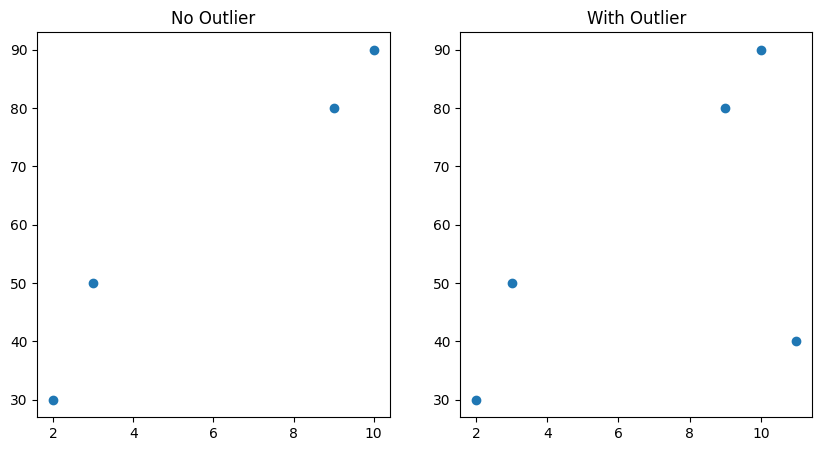

In [ ]:
# 원본 데이터 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.scatter(x1, y1)
plt.title('No Outlier') # 이상치 없음

plt.subplot(1,2,2)
plt.scatter(x2, y2)
plt.title('With Outlier') # 이상치 존재

- 공분산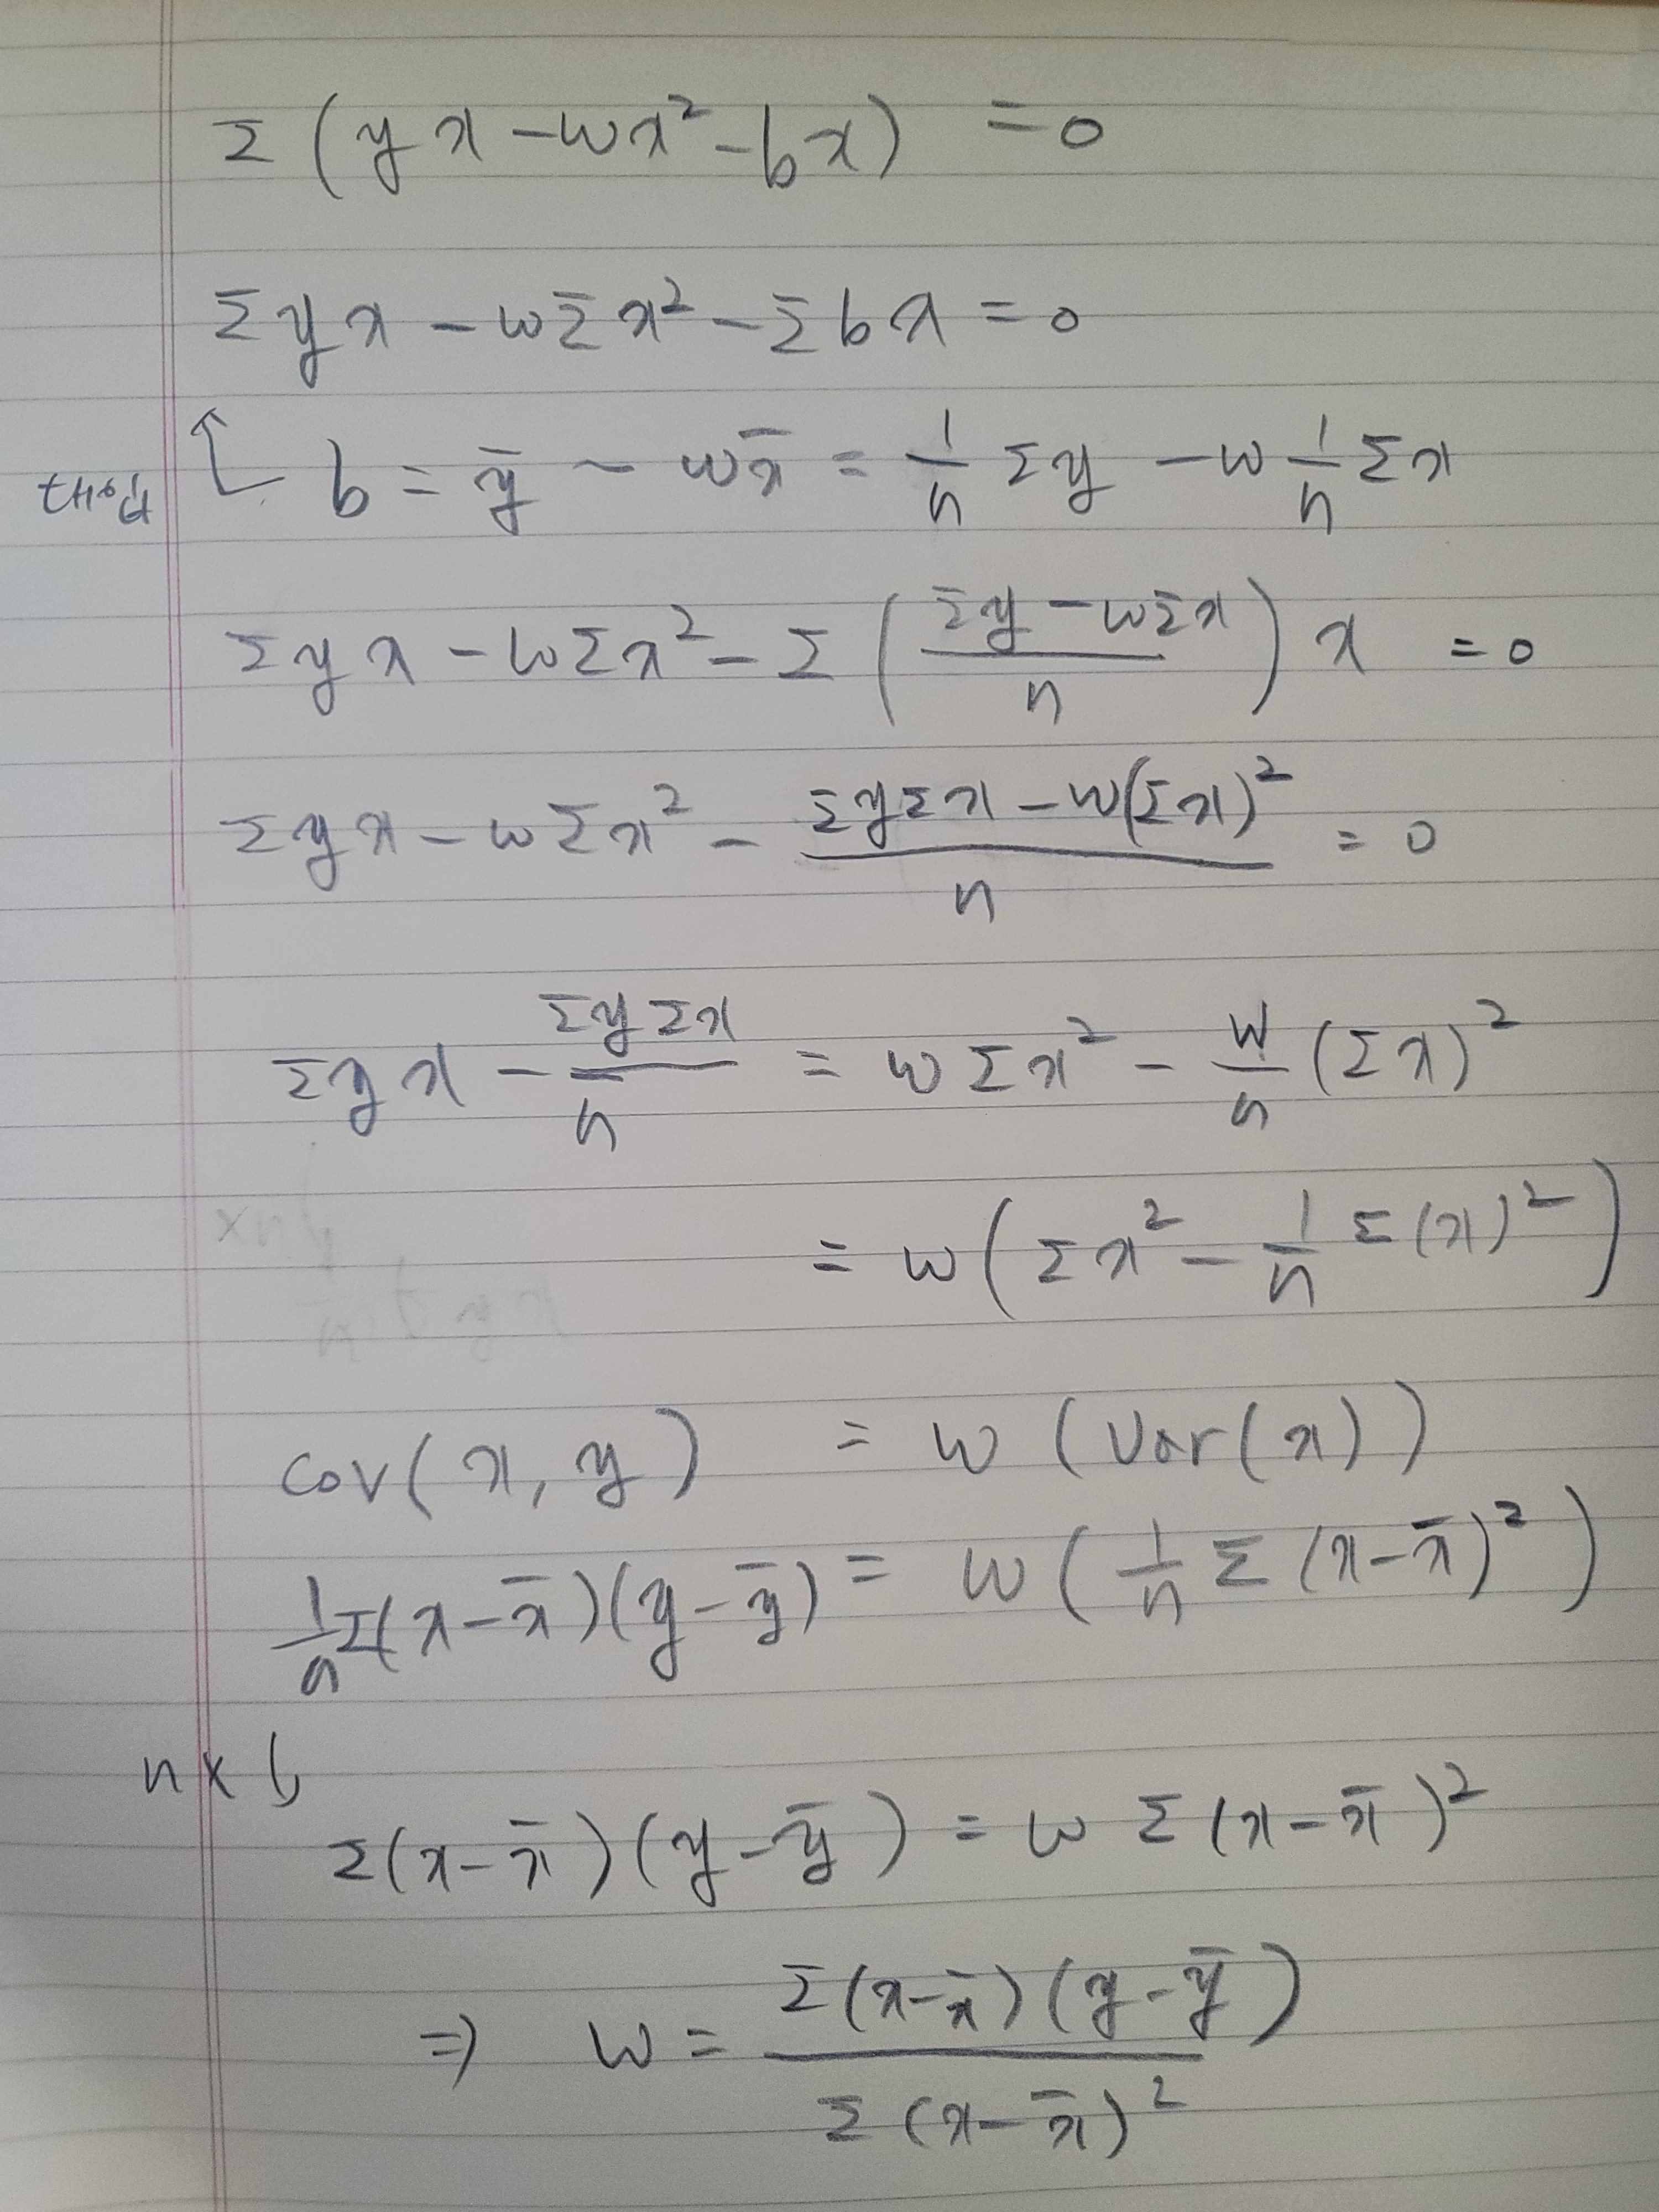

In [ ]:
# 최소제곱법 함수 구현
def OLS(x,y):
    w = np.sum(x.T@(y - y.mean())) / np.sum(x.T@(x - x.mean()))
    b = y.mean() - w*x.mean()
    return w, b

In [ ]:
# 공분산 식으로 구하기
def OLS2(x,y):
    w = np.sum((x - x.mean())*(y-y.mean())) / np.sum((x - x.mean())**2)
    b = y.mean() - w*x.mean()
    return w, b

In [ ]:
# OLS함수를 이용하여 가중치와 편향 계산
w1, b1 = OLS(x1, y1)
w2, b2 = OLS(x2, y2)

w1, b1, w2, b2

(6.6, 22.900000000000006, 3.4285714285714284, 34.0)

In [ ]:
w11, b11 = OLS2(x1, y1)
w21, b21 = OLS2(x2, y2)

w11, b11, w21, b21

(6.6, 22.900000000000006, 3.4285714285714284, 34.0)

In [ ]:
# 계산된 가중치와 편향을 이용하여 예측값 계산
y1_pred = w1*x1 + b1
y2_pred = w2*x2 + b2

Text(0.5, 1.0, 'With Outlier')

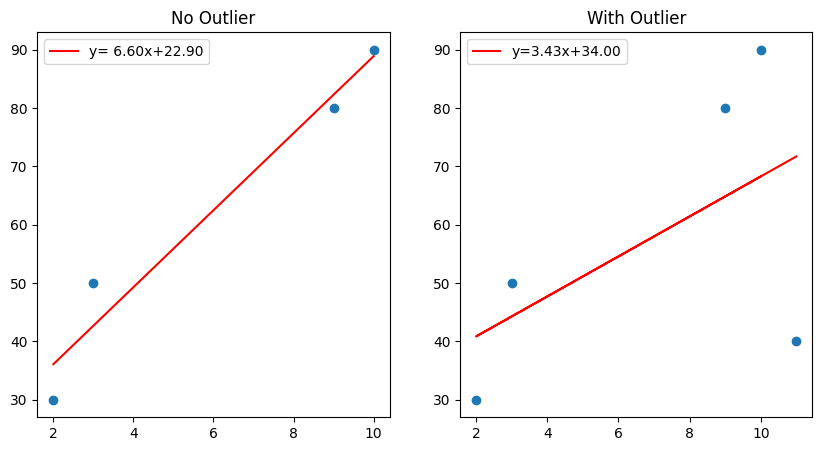

In [ ]:
# 예측값 포함 시각화
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.scatter(x1, y1)
plt.plot(x1, y1_pred, color='red', label=f"y={w1:.2f}x+{b1:.2f}")
plt.legend()
plt.title('No Outlier') # 이상치 없음

plt.subplot(1,2,2)
plt.scatter(x2, y2)
plt.plot(x2, y2_pred, color='red', label=f"y={w2:.2f}x+{b2:.2f}")
plt.legend()
plt.title('With Outlier') # 이상치 존재

### Scikit-Learn을 이용한 최소제곱법
- linear_model의 LinearRegression에 구현되어 있음
    - `coef_` : 가중치 값
    - `intercept_` : 편향 값
- 2차원 데이터에 대해서만 학습이 가능

In [ ]:
# sklearn을 사용한 최소제곱법
# x1, x2 회귀분석
from sklearn.linear_model import LinearRegression
model1 = LinearRegression()
# 1차원 데이터를 2차원 데이터로 변환
x1_2d = x1.reshape(-1,1)
x1.shape, x1_2d.shape
# 회귀분석
model1.fit(x1_2d, y1)
# 가중치편향
model1.coef_,model1.intercept_
# x가 많을 수록 coef_가 많아짐
# intercept는 그거에 대한 bias 확인할 수 있다
# 기울기 (6.6)
# → x가 1 증가할 때, y는 평균적으로 6.6만큼 증가한다는 의미입니다.
# 절편 (22.9)
# → x = 0일 때, y의 예상값은 22.9라는 뜻입니다.

(array([6.6]), 22.899999999999977)

In [ ]:
# x2, y2 회귀분석
model2 = LinearRegression()
# 1차원 데이터를 2차원 데이터로 변환
x2_2d = x2.reshape(-1,1)
# 회귀분석
model2.fit(x2_2d, y2) #model2에 대해서 학습을 해주고
# 가중치편향
model2.coef_,model2.intercept_ # 계산을 해보면
# [6]셀과 비교해 비슷한 것을 확인할 수 있다

(array([3.42857143]), 33.99999999999999)

> 직접 구현한 OLS함수의 결과와 동일

## 경사하강법(Gradient Descent)
- 가설(Hypothesis)에 의한 비용(Cost)이 최소화되는 직선을 구함
    - 가설 :
$H(x) = Wx + b$
- 비용을 계산하기 위해서 비용함수가 필요하며 주로 평균 제곱 오차(MSE) 함수를 사용함
    - 비용함수 :
$cost(W,b) = \frac{1}{m} \sum_{i=1}^m(H(x^{(i)}) - y^{(i)})^2$
- 비용 함수를 미분하여 비용이 낮아지는 방향으로 가중치 값을 변경하는 알고리즘
- 단점
    - 모든 학습데이터에 대해 반복적으로 비용함수를 최소화를 위한 값을 업데이트하기 때문에 수행시간이 매우 오래 걸림
        - 확률적 경사하강법(SGD, Stochastic Gradient Descent)를 이용

가설 w = 1, w = 2, w = 3 ... 각각의 w들에 대해 계산하고 <br> 그 비용을 계산
w가 변화함에 따라 cost(MSEe)가 최소가 되는 부분을 알아내는 것 <br>


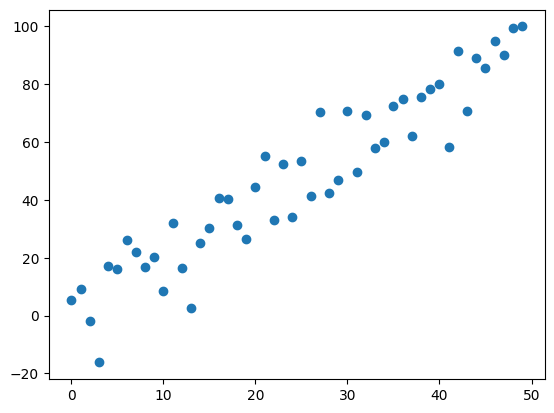

In [ ]:
# 경사하강법 - 구현
x = np.arange(50)
# x에 대해 가중치는 2로 설정하고, noise를 추가하여 y 계산
y = 2*x + 10*np.random.randn(50)
# x,y에 대해 시각화
plt.scatter(x,y)

Text(0, 0.5, 'Cost(W)')

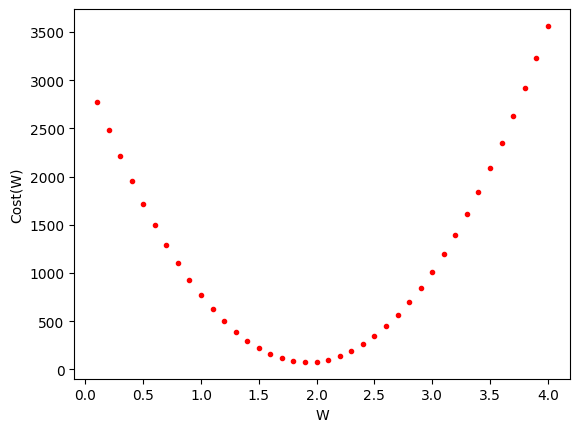

In [ ]:
# w값의 범위 정의
w_range = np.arange(0.1, 4.1, 0.1)
# 비용함수 계산 및 시각화
costs = []
for w in w_range:
    h = w * x # 편향을 제외한 계산 단순화 +b(bias)
    cost = 1/ 50 * np.sum((h - y)**2)
    costs.append(cost)

# 시각화
plt.plot(w_range, costs, 'r.') # 선으로 말고 red dot(r.)으로
plt.xlabel('W')
plt.ylabel('Cost(W)') # W에 대한 cost

- 비용함수는 볼록(Convex)함수이기 때문에 비용이 최소가 되는 가중치값을 찾기 위해 경사(Gradient)를 따라 내려가면 됨
    - 비용함수를 가중치(W)에 대해 편미분 <br>
$\frac{\partial cost(W)}{\partial W} = \frac{\partial}{\partial{W}} \sum_{i=1}^n (H(x^{(i)}) - y^{(i)})^2 = \frac{2}{m}\sum_{i=1}^n (H(x^{(i)}) - y^{(i)})x^{(i)}$
- 미분 결과에 따른 비용함수의 변화 시각화
    - 가중치 하강속도(learning_rate, lr)를 추가하여 현재 가중치값에서 빼는 것을 반복하다 보면 가장 작은 가중치를 찾을 수 있음 <br>
$W_{new} = W_{old} - lr \frac{\partial cost(W)}{\partial W}$

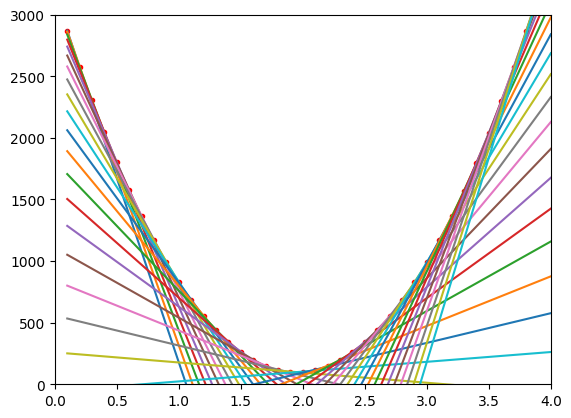

In [ ]:
# 가중치 값 변화 시각화
plt.plot(w_range, costs, 'r.')
for w, cost in zip(w_range, costs):
    h = w * x
    gradient = 2/50 * np.sum((h-y) * x)
    plt.plot(w_range, gradient * (w_range-w) + cost)
    plt.axis([0,4, 0,3000])

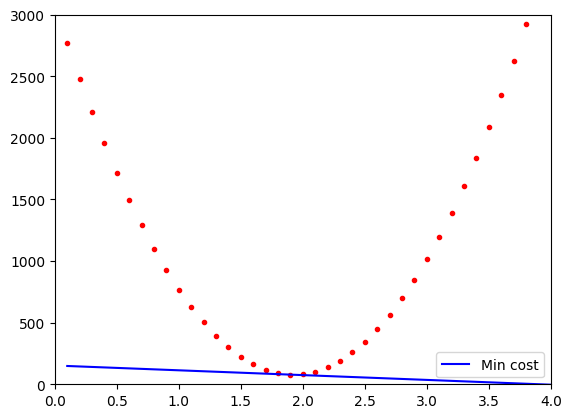

In [ ]:
# 비용이 최소가 되는 가중치 값 선정
# gradient가 최소가 되어야함
plt.plot(w_range, costs, 'r.')
gradients = []
for w, cost in zip(w_range, costs):
    h = w * x
    gradient = 2/50 * np.sum((h - y) *x)
    gradients.append(gradient)

idx = np.argmin(costs)
plt.plot(w_range, gradients[idx]*(w_range-w_range[idx])+costs[idx], 'b-', label="Min cost")
plt.axis([0,4, 0,3000])
plt.legend()

In [ ]:
w_range[idx]

2.0

https://abhisek1221.hashnode.dev/beyond-backpropagation-comprehensive-neural-network-optimization-guide

### [예제] 당뇨병 진행정도 예측
- baseline에서 1년뒤 증가할 당뇨병의 증감량(Target) 예측

In [31]:
# 데이터 추출
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()
print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [40]:
diabetes.feature_names

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

In [39]:
# 데이터 분할
from sklearn.model_selection import train_test_split
X_train, X_test, y_train,y_test = train_test_split(diabetes.data,
                                                   diabetes.target,
                                                   test_size = 0.3,
                                                   random_state=0)

In [42]:
# 모델 학습 및 평가
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(X_train, y_train)

# 성능지표 R^2(R-square)
print('Train 성능 : ', reg.score(X_train,y_train))
print('Test 성능 :', reg.score(X_test, y_test))

학습 성능 :  0.553937891544893
테스트 성능 : 0.39289927216962905


In [44]:
# 성능지표 MSE
# MSE는 error이기 때문에 낮은게 좋음
from sklearn.metrics import mean_squared_error # MAE 는 mean_absolute_error
train_pred = reg.predict(X_train) # 학습한것 기준으로 predict
test_pred = reg.predict(X_test) #테스트 한것 predict

print('Train 성능(MSE) : ', mean_squared_error(y_train,train_pred))
print('Test 성능(MSE) : ', mean_squared_error(y_test, test_pred))

# 에러의 제곱한 값의 평균이 높다

Train 성능(MSE) :  2804.1435610448802
Test 성능(MSE) :  3097.1191634246097


In [45]:
# 가중치와 편향 확인
reg.coef_, reg.intercept_
# 첫번째 -52.46478548 : 음의 상관관계

(array([ -52.46478548, -193.50733393,  579.49108514,  272.453666  ,
        -504.64830389,  241.62372969,  -69.76596029,   86.61313961,
         721.92083806,   26.78067442]),
 153.71901624380382)

In [ ]:
# 성능이 좋지 않다.
# 그렇다면 어떻게 분석해볼까
# 다항 회귀분석으로 바꿔보자 ↓

## Polynominal Regression (다항 회귀 분석)
- 연속형 레이블과 특성 간의 관계가 선형이 아닌 경우 1차식으로 표현이 불가능하여 2차식 이상의 다항식으로 변형하여 회귀분석을 진행해야 함
- **기존의 특성에 다항 변환을 적용**하여 새로운 특성을 추가
- PolynomialFeatures 객체를 이용하여 다항 변환 및 상호 교차항을 쉽게 추가 가능
```
sklearn.preprocessing.PolynomialFeatures
```
    - degree : 차수 (int or tuple (min_degree, max_degree), default=2)
    - include_bias : 편향(상수항) 포함 유무 (bool, default=True)
    - interaction_only : 상호교차항만 반환 유무 (bool, default=False)
        - False : 각 특성에 대한 다항식을 포함 <br>
            예: (degree = 2) x[0], x[1], x[0]^2, x[0]*x[1], x[1]^2
        - True : 상호교차항만 포함  
            예: (degree = 2) x[0], x[1], x[0]*x[1]

In [47]:
import pandas as pd
# x0 특성에 대해 2차항 반환(상수항 포함)
x = np.arange(5).reshape(-1,1)
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=True) # include_bias : 상수항 포함
pd.DataFrame(poly.fit_transform(x), columns = poly.get_feature_names_out())

,1,x0,x0^2
0,1.0,0.0,0.0
1,1.0,1.0,1.0
2,1.0,2.0,4.0
3,1.0,3.0,9.0
4,1.0,4.0,16.0


In [49]:
# x0, x1 특성에 대해 2차항 반환(상수항 포함)
x = np.arange(10).reshape(-1,2)
poly = PolynomialFeatures(degree=2, include_bias=True)
pd.DataFrame(poly.fit_transform(x), columns = poly.get_feature_names_out())

,1,x0,x1,x0^2,x0 x1,x1^2
0,1.0,0.0,1.0,0.0,0.0,1.0
1,1.0,2.0,3.0,4.0,6.0,9.0
2,1.0,4.0,5.0,16.0,20.0,25.0
3,1.0,6.0,7.0,36.0,42.0,49.0
4,1.0,8.0,9.0,64.0,72.0,81.0


In [50]:
# 상호교차항만 적용 (상수항 미포함)
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
pd.DataFrame(poly.fit_transform(x), columns = poly.get_feature_names_out())

,x0,x1,x0 x1
0,0.0,1.0,0.0
1,2.0,3.0,6.0
2,4.0,5.0,20.0
3,6.0,7.0,42.0
4,8.0,9.0,72.0


In [51]:
# 상호교차항만 적용 (상수항 포함)
poly = PolynomialFeatures(degree=2, include_bias=True, interaction_only=True)
pd.DataFrame(poly.fit_transform(x), columns = poly.get_feature_names_out())

,1,x0,x1,x0 x1
0,1.0,0.0,1.0,0.0
1,1.0,2.0,3.0,6.0
2,1.0,4.0,5.0,20.0
3,1.0,6.0,7.0,42.0
4,1.0,8.0,9.0,72.0


In [52]:
# 당뇨병 데이터 다항식으로 변환 (상수항 제외)
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_data_poly2 = poly2.fit_transform(diabetes.data)
diabetes.data.shape, X_data_poly2.shape
# 특성의 개수가 늘어난 것을 확인할 수 있다.

((442, 10), (442, 65))

In [54]:
# 다항식 특성을 포함한 데이터 분할
X_train_poly2, X_test_poly2, y_train, y_test = train_test_split(X_data_poly2,
                                                                diabetes.target,
                                                                test_size=0.3,
                                                                random_state=0)

In [58]:
# 모델 학습 및 평가
reg_poly2 = LinearRegression()
reg_poly2.fit(X_train_poly2, y_train)

train_poly2_score = reg_poly2.score(X_train_poly2, y_train)
test_poly2_score = reg_poly2.score(X_test_poly2, y_test)

print("선형회귀")
print("Train 성능 : ", reg.score(X_train, y_train))
print("Test 성능 : ", reg.score(X_test, y_test))

print("2차항 회귀")
print("Train 성능 : ", train_poly2_score)
print("Test 성능 : ", test_poly2_score)

선형회귀
Train 성능 :  0.553937891544893
Test 성능 :  0.39289927216962905
2차항 회귀
Train 성능 :  0.6569756197470977
Test 성능 :  0.2253537278852088


In [59]:
# 3차 다항식으로 변환
poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_data_poly3 = poly3.fit_transform(diabetes.data)
diabetes.data.shape, X_data_poly3.shape

# 데이터 분할
X_train_poly3, X_test_poly3, y_train, y_test = train_test_split(X_data_poly3,
                                                                diabetes.target,
                                                                test_size=0.3,
                                                                random_state=0)

# 모델 학습
reg_poly3 = LinearRegression()
reg_poly3.fit(X_train_poly3, y_train)

# 성능 평가
train_poly3_score = reg_poly3.score(X_train_poly3, y_train)
test_poly3_score = reg_poly3.score(X_test_poly3, y_test)
print("Train 성능 : ", train_poly3_score)
print("Test 성능 : ", test_poly3_score)

Train 성능 :  0.947304499563716
Test 성능 :  -65.8505256738428


In [60]:
# 5차 다항식으로 변환
poly5 = PolynomialFeatures(degree=5, include_bias=False)
X_data_poly5 = poly5.fit_transform(diabetes.data)
diabetes.data.shape, X_data_poly5.shape

# 데이터 분할
X_train_poly5, X_test_poly5, y_train, y_test = train_test_split(X_data_poly5,
                                                                diabetes.target,
                                                                test_size=0.3,
                                                                random_state=0)

# 모델 학습
reg_poly5 = LinearRegression()
reg_poly5.fit(X_train_poly5, y_train)

# 성능 평가
train_poly5_score = reg_poly5.score(X_train_poly5, y_train)
test_poly5_score = reg_poly5.score(X_test_poly5, y_test)
print("Train 성능 : ", train_poly5_score)
print("Test 성능 : ", test_poly5_score)

Train 성능 :  1.0
Test 성능 :  -22.18089057973265


# [실습] 보스턴 주택가격 예측
- [boston 데이터](https://drive.google.com/file/d/17ygxKFk3IyOhe6lIWm1OBqUY6eeDq3I8/view?usp=sharing) 다운로드
- [boston 데이터 설명](https://docs.google.com/spreadsheets/d/1zBof_87i06KVjoclAGjdgXpNS-tplSeF/edit?usp=sharing&ouid=102845530982678381052&rtpof=true&sd=true)
1. 선형회귀를 통해 보스턴 주택가격 예측
2. 다항회귀를 통해 보스턴 주택가격 예측
    - 아래의 인자들을 변경하면서 어떤 다항회귀가 가장 좋은 값을 나타내는지 확인
        - degree : 2,3
        - include_bias : True, False
        - interaction_only : True, False
    - 선형회귀와 비교하였을때는?
    

- 선형회귀 : scikit-Learn 이용한 최소제곱법

In [61]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [62]:
import pandas as pd
boston = pd.read_csv('/content/drive/MyDrive/boston.csv')
boston.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [64]:
# 분리하기 위해 타겟값 설정
X = boston.drop(columns=['MEDV'])
y = boston['MEDV']
X.shape, y.shape

((506, 13), (506,))

In [66]:
# 데이터 분할
from sklearn.model_selection import train_test_split
X_train_boston, X_test_boston, y_train_boston, y_test_boston = train_test_split(X , y,
                                                    test_size = 0.3,
                                                    random_state=0)

In [109]:
# score 저장 위한 데이터 프레임
all_scores = pd.DataFrame(columns = ['Degree', 'include_bias', 'interaction_only', 'train_score', 'test_score'])

In [68]:
# 모델 학습
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(X_train_boston, y_train_boston)

# 모델 평가 (R^2)
# 에 가까울수록 좋은 모델이고, 0에 가까울수록 설명력이 낮음.
# 오차의 실제 크기를 알 수는 없다
print("Train 성능 : ", reg.score(X_train_boston, y_train_boston))
print("Test 성능 : ", reg.score(X_test_boston, y_test_boston))

Train 성능 :  0.7645451026942549
Test 성능 :  0.6733825506400162


In [111]:
all_scores.loc[len(all_scores)] = [1, False, False, reg.score(X_train_boston, y_train_boston), reg.score(X_test_boston, y_test_boston)]
all_scores

,Degree,include_bias,interaction_only,train_score,test_score
4,1,False,False,0.764545,0.673383
1,1,False,False,0.764545,0.673383


In [70]:
from sklearn.metrics import mean_squared_error

train_pred_boston = reg.predict(X_train_boston)
test_pred_boston = reg.predict(X_test_boston)

# MSE는 예측값과 실제값의 차이를 제곱하여 평균을 구한 것 (오차의 크기를 파악 가능)
# 값이 작을수록 예측이 더 정확함.
# 단점: 값이 너무 크거나 작아서 해석이 어려울 수 있음 (그래서 RMSE를 쓰기도 함).
print("Train 성능(MSE):", mean_squared_error(y_train_boston, train_pred_boston))
print("Test 성능(MSE):", mean_squared_error(y_test_boston, test_pred_boston))

# 테스트 데이터의 MSE가 더 크다는 것은 모델이 훈련 데이터에는 잘 맞지만, 새로운 데이터(테스트 데이터)에서는 성능이 조금 떨어진다는 의미

Train 성능(MSE): 19.958219814238046
Test 성능(MSE): 27.195965766883493


In [71]:
reg.coef_, reg.intercept_

(array([-1.21310401e-01,  4.44664254e-02,  1.13416945e-02,  2.51124642e+00,
        -1.62312529e+01,  3.85906801e+00, -9.98516565e-03, -1.50026956e+00,
         2.42143466e-01, -1.10716124e-02, -1.01775264e+00,  6.81446545e-03,
        -4.86738066e-01]),
 37.937107741833955)

- 다항회귀분석

In [76]:
# 1. degree = 2 , include_bias = True , inteaction_only=True
# 데이터 다항식으로 변환 상호교차항만 적용 (상수항 포함)
import numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree = 2, include_bias = True , interaction_only=True)
X_data_poly_boston1 = poly.fit_transform(X)
X.shape, X_data_poly_boston1.shape

((506, 13), (506, 92))

In [78]:
# 다항식 특성 포함한 데이터 분할
from sklearn.model_selection import train_test_split
X_train_poly_boston1, X_test_poly_boston1, y_train, y_test= train_test_split(X_data_poly_boston1,
                                                                             y,
                                                                             test_size = 0.3,
                                                                             random_state = 0)

In [80]:
# 모델 학습 및 평가
reg_boston_poly1 = LinearRegression()
reg_boston_poly1.fit(X_train_poly_boston1, y_train)

train_poly1_boston_score = reg_boston_poly1.score(X_train_poly_boston1, y_train)
test_poly1_boston_score = reg_boston_poly1.score(X_test_poly_boston1, y_test)


print("선형 회귀")
print("Train 성능 : ", reg.score(X_train_boston, y_train_boston))
print("Test 성능 : ", reg.score(X_test_boston, y_test_boston))

print("1. 2차 다항 회귀")
print("Train 성능 : ", train_poly1_boston_score)
print("Test 성능 : ", test_poly1_boston_score)

선형 회귀
Train 성능 :  0.7645451026942549
Test 성능 :  0.6733825506400162
2차 다항 회귀
Train 성능 :  0.9405114731852501
Test 성능 :  0.7430494619420219


In [81]:
# 2. degree = 2 , include_bias = False , inteaction_only=True
poly2 = PolynomialFeatures(degree = 2, include_bias = False , interaction_only=True)
X_data_poly_boston2 = poly2.fit_transform(X)
X.shape, X_data_poly_boston2.shape

((506, 13), (506, 91))

In [82]:
# 다항식 특성 포함한 데이터 분할
from sklearn.model_selection import train_test_split
X_train_poly_boston2, X_test_poly_boston2, y_train, y_test= train_test_split(X_data_poly_boston2,
                                                                             y,
                                                                             test_size = 0.3,
                                                                             random_state = 0)

In [83]:
# 모델 학습 및 평가
reg_boston_poly2 = LinearRegression()
reg_boston_poly2.fit(X_train_poly_boston2, y_train)

train_poly2_boston_score = reg_boston_poly2.score(X_train_poly_boston2, y_train)
test_poly2_boston_score = reg_boston_poly2.score(X_test_poly_boston2, y_test)

print("2. 2차 다항 회귀")
print("Train 성능 : ", train_poly2_boston_score)
print("Test 성능 : ", test_poly2_boston_score)

2. 2차 다항 회귀
Train 성능 :  0.94051147318525
Test 성능 :  0.7430494619455714


In [84]:
# 3. degree = 2 , include_bias = True , inteaction_only= False
#  기본 값이 설정되어있음
poly3 = PolynomialFeatures()
X_data_poly_boston3 = poly3.fit_transform(X)
X.shape, X_data_poly_boston3.shape

((506, 13), (506, 105))

In [85]:
# 다항식 특성 포함한 데이터 분할
from sklearn.model_selection import train_test_split
X_train_poly_boston3, X_test_poly_boston3, y_train, y_test= train_test_split(X_data_poly_boston3,
                                                                             y,
                                                                             test_size = 0.3,
                                                                             random_state = 0)

In [86]:
# 모델 학습 및 평가
reg_boston_poly3 = LinearRegression()
reg_boston_poly3.fit(X_train_poly_boston3, y_train)

train_poly3_boston_score = reg_boston_poly3.score(X_train_poly_boston3, y_train)
test_poly3_boston_score = reg_boston_poly3.score(X_test_poly_boston3, y_test)

print("2. 2차 다항 회귀")
print("Train 성능 : ", train_poly3_boston_score)
print("Test 성능 : ", test_poly3_boston_score)

2. 2차 다항 회귀
Train 성능 :  0.9517246762476056
Test 성능 :  0.6486839500015825


In [89]:
# 4. degree = 2 , include_bias = False , interaction_only= False
poly4 = PolynomialFeatures(include_bias = False)
X_data_poly_boston4 = poly4.fit_transform(X)
X.shape, X_data_poly_boston4.shape

((506, 13), (506, 104))

- degree = 3

In [90]:
# 5. degree = 3 , include_bias = True , interaction_only=True
poly5 = PolynomialFeatures(degree=3,include_bias = True , interaction_only=True)
X_data_poly_boston5 = poly5.fit_transform(X)
X.shape, X_data_poly_boston5.shape

((506, 13), (506, 378))

In [91]:
# 데이터 분할
X_train_poly_boston5, X_test_poly_boston5, y_train, y_test = train_test_split(X_data_poly_boston5,
                                                                              y,
                                                                              test_size=0.3,
                                                                              random_state=0)

In [93]:
# 데이터 학습
reg_boston_poly5 = LinearRegression()
reg_boston_poly5.fit(X_train_poly_boston5, y_train)

# 성능 평가
train_poly5_boston_score = reg_boston_poly5.score(X_train_poly_boston5, y_train)
test_poly5_boston_score = reg_boston_poly5.score(X_test_poly_boston5, y_test)

print("5. 3차 다항 회귀")
print("Train 성능 : ", train_poly5_boston_score)
print("Test 성능 : ", test_poly5_boston_score)

5. 3차 다항 회귀
Train 성능 :  0.992566146592742
Test 성능 :  -87.24040055966348


In [95]:
# 6. degree = 3 , include_bias = True , interaction_only=False
poly6 = PolynomialFeatures(degree=3, interaction_only = False)
X_data_poly_boston6 = poly6.fit_transform(X)
print(X.shape, X_data_poly_boston6.shape)

# 데이터 분할
X_train_poly_boston6, X_test_poly_boston6, y_train, y_test = train_test_split(X_data_poly_boston6,
                                                                              y,
                                                                              test_size=0.3,
                                                                              random_state=0)
# 모델 학습
reg_boston_poly6 = LinearRegression()
reg_boston_poly6.fit(X_train_poly_boston6, y_train)

# 성능 평가
train_poly6_boston_score = reg_boston_poly6.score(X_train_poly_boston6, y_train)
test_poly6_boston_score = reg_boston_poly6.score(X_test_poly_boston6, y_test)

print("6. 3차 다항 회귀")
print("Train 성능 : ", train_poly6_boston_score)
print("Test 성능 : ", test_poly6_boston_score)



(506, 13) (506, 560)
6. 3차 다항 회귀
Train 성능 :  1.0
Test 성능 :  -1030.7847769093478


In [97]:
# 7. degree = 3 , include_bias = False , interaction_only=True
poly7 = PolynomialFeatures(degree=3, include_bias = False , interaction_only=True)
X_data_poly_boston7 = poly7.fit_transform(X)
print(X.shape, X_data_poly_boston7.shape)

# 데이터 분할
X_train_poly_boston7, X_test_poly_boston7, y_train, y_test = train_test_split(X_data_poly_boston7,
                                                                              y,
                                                                              test_size=0.3,
                                                                              random_state=0)
# 모델 학습
reg_boston_poly7 = LinearRegression()
reg_boston_poly7.fit(X_train_poly_boston7, y_train)

# 성능 평가
train_poly7_boston_score = reg_boston_poly7.score(X_train_poly_boston7, y_train)
test_poly7_boston_score = reg_boston_poly7.score(X_test_poly_boston7, y_test)

print("7. 3차 다항 회귀")
print("Train 성능 : ", train_poly7_boston_score)
print("Test 성능 : ", test_poly7_boston_score)

(506, 13) (506, 377)
7. 3차 다항 회귀
Train 성능 :  0.9925661465912263
Test 성능 :  -86.90524785890729


In [98]:
# 8. degree = 3 , include_bias = False , interaction_only = False
poly8 = PolynomialFeatures(degree=3, include_bias = False , interaction_only=False)
X_data_poly_boston8 = poly8.fit_transform(X)
print(X.shape, X_data_poly_boston8.shape)

# 데이터 분할
X_train_poly_boston8, X_test_poly_boston8, y_train, y_test = train_test_split(X_data_poly_boston8,
                                                                              y,
                                                                              test_size=0.3,
                                                                              random_state=0)
# 모델 학습
reg_boston_poly8 = LinearRegression()
reg_boston_poly8.fit(X_train_poly_boston8, y_train)

# 성능 평가
train_poly8_boston_score = reg_boston_poly8.score(X_train_poly_boston8, y_train)
test_poly8_boston_score = reg_boston_poly8.score(X_test_poly_boston8, y_test)

print("8. 3차 다항 회귀")
print("Train 성능 : ", train_poly8_boston_score)
print("Test 성능 : ", test_poly8_boston_score)

(506, 13) (506, 559)
8. 3차 다항 회귀
Train 성능 :  1.0
Test 성능 :  -1030.7847809395507


### 강사님 풀이

In [ ]:
# 데이터 추출
import pandas as pd
boston = pd.read_csv('/content/boston.csv')
X_data = boston.drop(columns='MEDV')
y_data = boston['MEDV']

In [ ]:
# 데이터 분할
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.3, random_state=42)

In [ ]:
# score를 저장할 데이터프레임 만들기
scores = pd.DataFrame(columns=["Degree", 'include_bias', ' interaction_only', "train score", "test score"])

In [ ]:
# 선형회귀
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(X_train, y_train)

reg.score(X_train, y_train), reg.score(X_test, y_test)

(0.7434997532004697, 0.7112260057484936)

In [ ]:
scores.loc[len(scores)] = [1, False, False, reg.score(X_train, y_train), reg.score(X_test, y_test)]
scores

,Degree,include_bias,interaction_only,train score,test score
0,1,False,False,0.7435,0.711226


In [ ]:
# 다항회귀
from sklearn.preprocessing import PolynomialFeatures
degrees = [2,3,5]
bias_TF = [True, False]
interaction_TF = [True, False]

for d in degrees:
    for b in bias_TF:
        for i in interaction_TF:
            poly = PolynomialFeatures(degree=d, include_bias=b, interaction_only=i)
            X_poly = poly.fit_transform(X_data)
            X_train, X_test, y_train, y_test = train_test_split(X_poly, y_data, test_size=0.3, random_state=42)
            reg = LinearRegression()
            reg.fit(X_train,y_train)
            print([reg.score(X_train, y_train), reg.score(X_test, y_test)])
            scores.loc[len(scores)] = [d, b, i, reg.score(X_train, y_train), reg.score(X_test, y_test)]

[0.9362183440264872, 0.7809740006024157]
[0.9469794920108193, 0.6610321968968728]
[0.9362183440264866, 0.7809740006124584]
[0.9469794920108199, 0.661032196917398]
[0.9953542020460577, -280.6893065507236]
[1.0, -376.6928448267149]
[0.9953542012715971, -281.2499854781124]
[1.0, -376.6928446125803]
[1.0, -490.9701562268508]
[1.0, -866.0873403810325]
[1.0, -490.9701563308018]
[1.0, -866.0873404480338]


In [ ]:
scores.sort_values('test score', ascending=False)

,Degree,include_bias,interaction_only,train score,test score
3,2,False,True,0.936218,0.780974
1,2,True,True,0.936218,0.780974
0,1,False,False,0.743500,0.711226
4,2,False,False,0.946979,0.661032
2,2,True,False,0.946979,0.661032
5,3,True,True,0.995354,-280.689307
7,3,False,True,0.995354,-281.249985
8,3,False,False,1.000000,-376.692845
6,3,True,False,1.000000,-376.692845
9,5,True,True,1.000000,-490.970156


In [ ]:
# statsmodels를 이용한 최소제곱법
import statsmodels.api as sm
model = sm.OLS(y_train, X_train)
result = model.fit()
print(result.summary())

                                 OLS Regression Results                                
Dep. Variable:                   MEDV   R-squared (uncentered):                   0.961
Model:                            OLS   Adj. R-squared (uncentered):              0.959
Method:                 Least Squares   F-statistic:                              639.0
Date:                Fri, 21 Feb 2025   Prob (F-statistic):                   2.28e-230
Time:                        08:23:54   Log-Likelihood:                         -1067.4
No. Observations:                 354   AIC:                                      2161.
Df Residuals:                     341   BIC:                                      2211.
Df Model:                          13                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------